# OptiScore — 선수 시장 가치 예측 모델 (통합 모델)

5대 리그(분데스리가/라리가/프리미어리그/세리에A/리그1) 필드 플레이어의 시즌 스탯으로
Transfermarkt 시장 가치를 예측한다. **포지션을 원-핫 피처로 받는 단일 XGBoost 모델
하나**로 8개 포지션을 전부 처리한다 (`ml/train.py`의 `train_pooled`).

이 노트북은 실제 학습 파이프라인인 [`ml/train.py`](../train.py)와
[`backend/features.py`](../../backend/features.py)를 그대로 불러와서 실행한다 —
로직을 노트북에 다시 손코딩하지 않는 이유는, 이전 버전에서 학습 코드와 서빙(예측
API) 코드에 피처 엔지니어링을 각각 손코딩했다가 `'태클'` vs `'태클 성공'` 같은
불일치 버그가 생겼기 때문이다.

**여기까지 온 과정** (자세한 수치는 [`../reports/model_evaluation.md`](../reports/model_evaluation.md)):

| 라운드 | 내용 | 평균 CV R² |
|---|---|---|
| 0 (원본) | 포지션별 모델 8개, 랜덤 분할(데이터 누수 있음) | — |
| 1 | 버그 수정: 모델 전부 저장, 스케일러 제거, `GroupShuffleSplit` | 66.0% |
| 2 | 새 피처 3종(리그/커리어시즌차수/2시즌평균) + Optuna 재탐색 + XGBoost·LightGBM 비교 | 71.8% |
| 3 | 평가 방법론: 단일 분할 불안정성 발견 → GroupKFold 4-fold 공식화, 포지션 라벨 정리(효과 없었음) | 71.8% |
| **4 (현재)** | **포지션별 8개 모델 → 포지션을 피처로 넣은 통합 모델 1개** | **77.3%** |

4라운드가 가장 큰 개선이었다 — 표본이 적은 포지션(측면 미드필더, 343건)이 전체
11,637행에서 학습된 공통 패턴(나이 곡선, 리그 효과)의 혜택을 받을 수 있어서
44.3%→65.1%로 뛰었다. AutoGluon(CatBoost/신경망 포함 AutoML)과도 비교했는데
근소하게 더 좋았지만(+0.8%p) 배포 복잡도 대비 이득이 작아 채택하지 않았다
(`ml/experiment_autogluon.py`).

In [1]:
%matplotlib inline
import sys
from pathlib import Path

ROOT = Path.cwd().resolve().parents[1]
sys.path.insert(0, str(ROOT / "backend"))
sys.path.insert(0, str(ROOT / "ml"))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

import features
import train as train_module

pd.set_option("display.max_columns", 20)
sns.set_style("whitegrid")

## 1. 데이터 로딩 · 클리닝 · 피처 엔지니어링

In [2]:
raw = train_module.load_raw()
df = train_module.load_data()
print(f"학습 대상: {len(df):,}건, 선수 {df['name_key'].nunique():,}명, 포지션 그룹 {df['포지션_그룹'].nunique()}개, 피처 후보 {df.shape[1]}개")
df[["name_key", "시즌", "포지션_그룹", "TM_시장가치_EUR", "log_현재_시장가치", "log_전시즌_시장가치"]].head()

학습 대상: 11,637건, 선수 3,929명, 포지션 그룹 8개, 피처 후보 86개


,name_key,시즌,포지션_그룹,TM_시장가치_EUR,log_현재_시장가치,log_전시즌_시장가치
7938,aaron connolly,2019-2020,스트라이커,3666667.0,15.114794,0.000000
7179,aaron cresswell,2016-2017,중앙 수비수,12000000.0,16.300417,0.000000
7358,aaron cresswell,2017-2018,중앙 수비수,12000000.0,16.300417,16.300417
7573,aaron cresswell,2018-2019,중앙 수비수,10000000.0,16.118096,16.300417
7896,aaron cresswell,2019-2020,중앙 수비수,7500000.0,15.830414,16.118096


## 2. 통합 모델 학습 및 평가

`train_pooled()`는:
- `ml/reports/best_params_pooled.json`(`ml/tune_pooled.py` 재탐색 결과)에서
  XGBoost/LightGBM 중 "포지션별 CV R² 평균"이 더 높은 쪽 파라미터를 가져온다.
- 선수 단위 `GroupKFold`(4-fold)로 학습·평가하되, **포지션별로도 R²를 슬라이스**해서
  통합 모델이 각 포지션에서 실제로 얼마나 잘하는지 따로 본다.
- 별도의 단일 분할로 저장할 모델 하나를 학습하고, 피처 중요도·오차 분석 예시를 뽑는다.

In [3]:
bundle, results = train_module.train_pooled(df)

통합 모델 [xgboost] 학습 중... (n=11637, 피처 68개)


  공격형 미드필더: CV R²=80.55% (±3.00%)
  수비형 미드필더: CV R²=80.05% (±3.97%)
  스트라이커: CV R²=80.93% (±1.57%)
  윙어: CV R²=74.50% (±4.14%)
  중앙 미드필더: CV R²=79.80% (±2.07%)
  중앙 수비수: CV R²=80.41% (±0.64%)
  측면 미드필더: CV R²=65.09% (±11.80%)
  측면 수비수: CV R²=76.97% (±2.94%)

랜덤분할 R²=82.18% | 전체 풀링 CV R²=79.62% | 포지션별 평균 CV R²=77.29%


In [4]:
summary = pd.DataFrame([
    {
        "포지션": pos,
        "표본수": info["n_rows"],
        "CV R²": info["cv_split"]["r2_mean"],
        "CV 표준편차": info["cv_split"]["r2_std"],
    }
    for pos, info in results["by_position"].items()
]).sort_values("CV R²", ascending=False)

print(f"모델: {results['model_type']} | 전체 풀링 CV R²: {results['overall_cv_r2']:.1%} | 포지션별 평균 CV R²: {results['macro_cv_r2']:.1%}")
summary.style.format({"CV R²": "{:.1%}", "CV 표준편차": "{:.1%}"})

모델: xgboost | 전체 풀링 CV R²: 79.6% | 포지션별 평균 CV R²: 77.3%


,포지션,표본수,CV R²,CV 표준편차
2,스트라이커,1767,80.9%,1.6%
0,공격형 미드필더,1012,80.6%,3.0%
5,중앙 수비수,2511,80.4%,0.6%
1,수비형 미드필더,1381,80.1%,4.0%
4,중앙 미드필더,1455,79.8%,2.1%
7,측면 수비수,1806,77.0%,2.9%
3,윙어,1362,74.5%,4.1%
6,측면 미드필더,343,65.1%,11.8%


C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_31384\374512876.py:10: UserWarning: Glyph 49828 (\N{HANGUL SYLLABLE SEU}) missing from font(s) Arial.
  fig.tight_layout()
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_31384\374512876.py:10: UserWarning: Glyph 53944 (\N{HANGUL SYLLABLE TEU}) missing from font(s) Arial.
  fig.tight_layout()
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_31384\374512876.py:10: UserWarning: Glyph 46972 (\N{HANGUL SYLLABLE RA}) missing from font(s) Arial.
  fig.tight_layout()
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_31384\374512876.py:10: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) Arial.
  fig.tight_layout()
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_31384\374512876.py:10: UserWarning: Glyph 52964 (\N{HANGUL SYLLABLE KEO}) missing from font(s) Arial.
  fig.tight_layout()
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_31384\374512876.py:10: UserWarning: Glyph 44277 (\N{

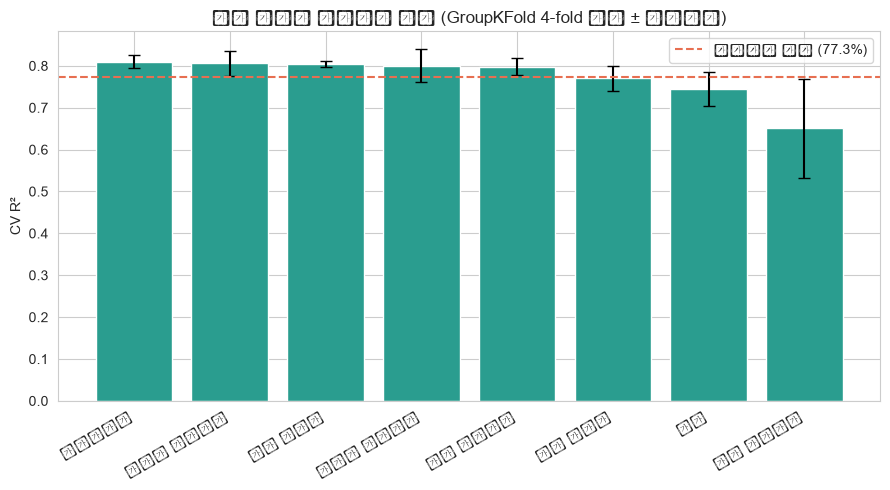

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))
x = range(len(summary))
ax.bar(x, summary["CV R²"], yerr=summary["CV 표준편차"], capsize=4, color="#2a9d8f")
ax.axhline(results["macro_cv_r2"], color="#e76f51", linestyle="--", label=f"포지션별 평균 ({results['macro_cv_r2']:.1%})")
ax.set_xticks(list(x))
ax.set_xticklabels(summary["포지션"], rotation=30, ha="right")
ax.set_ylabel("CV R²")
ax.set_title("통합 모델의 포지션별 성능 (GroupKFold 4-fold 평균 ± 표준편차)")
ax.legend()
fig.tight_layout()
plt.show()

측면 미드필더가 여전히 가장 낮고 표준편차도 가장 크지만(표본 343건), 포지션별
전용 모델을 썼을 때의 44.3%보다는 크게 나아졌다(65.1%). 다른 포지션들도 전부
전용 모델보다 개선됐다 — 자세한 전/후 비교는
[`model_evaluation.md`](../reports/model_evaluation.md) 0절 표 참고.

## 3. 피처 중요도

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_31384\80194997.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=imp_df, x="importance", y="feature", ax=ax, palette="viridis")
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_31384\80194997.py:8: UserWarning: Glyph 51204 (\N{HANGUL SYLLABLE JEON}) missing from font(s) Arial.
  fig.tight_layout()
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_31384\80194997.py:8: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) Arial.
  fig.tight_layout()
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_31384\80194997.py:8: UserWarning: Glyph 51596 (\N{HANGUL SYLLABLE JEUN}) missing from font(s) Arial.
  fig.tight_layout()
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_31384\80194997.py:8: UserWarning: Glyph 51109 (\N{HANGUL SYLLABLE JANG

C:\Users\SONGSH\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 53685 (\N{HANGUL SYLLABLE TONG}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\SONGSH\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 54633 (\N{HANGUL SYLLABLE HAB}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\SONGSH\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 47784 (\N{HANGUL SYLLABLE MO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\SONGSH\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Pytho

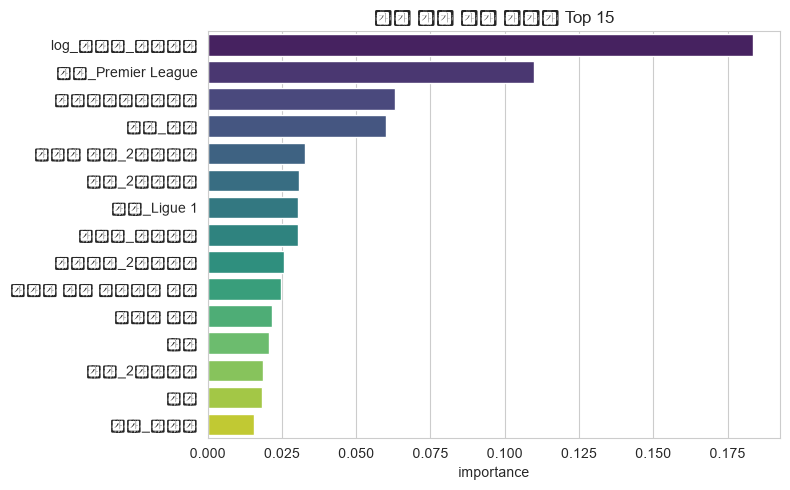

In [6]:
imp_df = pd.DataFrame(results["top_features"])

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=imp_df, x="importance", y="feature", ax=ax, palette="viridis")
ax.set_title("통합 모델 피처 중요도 Top 15")
ax.set_xlabel("importance")
ax.set_ylabel("")
fig.tight_layout()
plt.show()

`log_전시즌_시장가치`(작년 시장 가치)가 압도적 1위다. 시장가치는 원래 전년도
값과 강한 자기상관이 있어 자연스러운 결과이지만, 이 모델이 "성과로부터 가치를
추정"한다기보다 "작년 가격 + 보정"에 가깝다는 한계이기도 하다. 포지션 원-핫
피처들과 리그 원-핫(`리그_Premier League` 등)도 상위권에 들어, 이번에 추가한
피처들이 실제로 기여하고 있음을 확인할 수 있다.

## 4. 오차 분석 — 스트라이커 예시

In [7]:
example_position = "스트라이커"
under = pd.DataFrame(results["by_position"][example_position]["underrated_top5"])
over = pd.DataFrame(results["by_position"][example_position]["overrated_top5"])

print(f"[{example_position}] 과소평가 TOP 5 (모델이 실제보다 훨씬 낮게 예측)")
display(under)
print(f"\n[{example_position}] 과대평가 TOP 5 (모델이 실제보다 훨씬 높게 예측)")
display(over)

[스트라이커] 과소평가 TOP 5 (모델이 실제보다 훨씬 낮게 예측)


,선수명,실제_가치,예측_가치,오차
0,antoine griezmann,1.433333e+08,68655704.0,-7.467763e+07
1,erling haaland,1.933333e+08,123207112.0,-7.012622e+07
2,antoine griezmann,8.000000e+07,10454152.0,-6.954585e+07
3,erling haaland,1.050000e+08,35838152.0,-6.916185e+07
4,robert lewandowski,8.000000e+07,34186764.0,-4.581324e+07



[스트라이커] 과대평가 TOP 5 (모델이 실제보다 훨씬 높게 예측)


,선수명,실제_가치,예측_가치,오차
0,gabriel jesus,63000000.0,93111832.0,30111832.0
1,gabriel jesus,70000000.0,91210448.0,21210448.0
2,gabriel jesus,60000000.0,79610880.0,19610880.0
3,gabriel jesus,53333333.0,67641080.0,14307747.0
4,kai havertz,4833333.0,17626796.0,12793463.0


브랜드 가치·이적시장 하이프가 큰 선수는 통합 모델로 바꿔도 여전히 과소평가된다
— 시즌 스탯만으로는 설명되지 않는 "시장 프리미엄"이 있다는 뜻이다. 다른
포지션(윙어의 Son/Hazard/Saka, 중앙 수비수의 De Ligt 등)에서도 동일한 패턴이
반복된다 — 자세한 목록은 [`model_evaluation.md`](../reports/model_evaluation.md) 4절.

## 5. 잔차 분석

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_31384\1941847286.py:16: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) Arial.
  fig.tight_layout()
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_31384\1941847286.py:16: UserWarning: Glyph 52769 (\N{HANGUL SYLLABLE CEUG}) missing from font(s) Arial.
  fig.tight_layout()
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_31384\1941847286.py:16: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) Arial.
  fig.tight_layout()
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_31384\1941847286.py:16: UserWarning: Glyph 51109 (\N{HANGUL SYLLABLE JANG}) missing from font(s) Arial.
  fig.tight_layout()
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_31384\1941847286.py:16: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from font(s) Arial.
  fig.tight_layout()
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_31384\1941847286.py:16: UserWarning: Glyph 52

C:\Users\SONGSH\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\SONGSH\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 52769 (\N{HANGUL SYLLABLE CEUG}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\SONGSH\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\SONGSH\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python

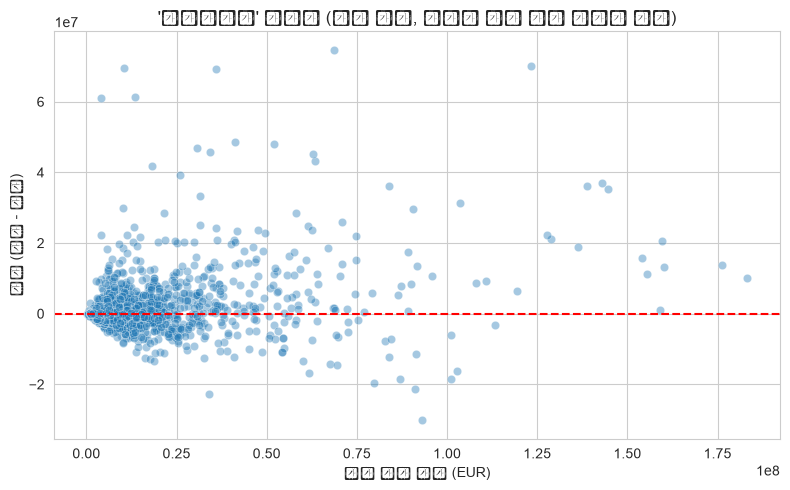

In [8]:
group_df = df[df["포지션_그룹"] == example_position].copy()
X = group_df[bundle["feature_cols"]].fillna(0)
y = group_df["log_현재_시장가치"]

log_pred = bundle["model"].predict(X)
y_pred = np.expm1(log_pred)
y_true = np.expm1(y)
residuals = y_true - y_pred

fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(x=y_pred, y=residuals, alpha=0.4, ax=ax)
ax.axhline(0, color="red", linestyle="--")
ax.set_xlabel("예측 시장 가치 (EUR)")
ax.set_ylabel("잔차 (실제 - 예측)")
ax.set_title(f"'{example_position}' 잔차도 (통합 모델, 학습에 쓰인 전체 데이터 기준)")
fig.tight_layout()
plt.show()

## 6. 모델 저장

통합 모델 하나를 `backend/models/model_bundle.pkl`에 저장한다
(`{model, feature_cols, model_type}` — 포지션별 8개가 아니라 단일 모델).
`backend/app.py`는 이 번들을 로드해서, 입력받은 포지션을 원-핫 피처 중 하나로
채운 뒤 이 모델 하나로 예측한다.

In [9]:
import joblib

BUNDLE_PATH = ROOT / "backend" / "models" / "model_bundle.pkl"
joblib.dump(bundle, BUNDLE_PATH)
print(f"저장 완료: {BUNDLE_PATH} (모델 타입: {bundle['model_type']}, 피처 {len(bundle['feature_cols'])}개)")

pred_df = train_module.predict_all_pooled(df, bundle)
out = train_module.build_prediction_excel(raw, pred_df)
out.to_excel(ROOT / "data" / "player_with_pred.xlsx", index=False)
print("예측 결과 저장 완료: data/player_with_pred.xlsx")

저장 완료: C:\Users\SONGSH\Desktop\capstone_design\backend\models\model_bundle.pkl (모델 타입: xgboost, 피처 68개)


예측 결과 저장 완료: data/player_with_pred.xlsx


## 7. 한계 및 향후 개선 과제

1. **측면 미드필더는 여전히 8개 중 가장 낮다** (343건/154명). 포지션 통합
   모델로 44.3%→65.1%까지 크게 개선됐지만, 표본 자체가 다른 포지션의 1/4~1/7
   수준이라는 근본 한계는 남아있다. 더 개선하려면 결국 더 많은 시즌/리그
   데이터가 필요하다.
2. **슈퍼스타 과소평가**: 시즌 스탯만으로는 브랜드/하이프 요인을 설명하지
   못한다. 아키텍처를 통합 모델로 바꿔도 해결되지 않는 구조적 한계로 재확인됐다.
3. **AutoGluon 대비 근소한 격차**: CatBoost·신경망까지 포함한 AutoML 앙상블이
   동일 조건에서 +0.8%p 더 좋았다. 배포 복잡도(PyTorch, Windows에서 Ray 기반
   배깅이 불안정) 대비 이득이 작아 채택하지 않았지만, 격차 자체가 사라진 건
   아니다.
4. **신인 선수**: "작년 시장 가치"가 없는 데뷔 시즌 선수에 대한 예측 정확도는
   별도 검증이 필요하다. `/api/predict`의 커리어 시즌차수·2시즌평균도 실시간
   입력에서는 근사치임을 감안해야 한다.
5. **더 엄격한 검증**: 지금의 선수 그룹 분할도 여전히 "무작위 선수"를 떼어내는
   것이라, 실제 배포 시나리오(과거 시즌으로 학습해 미래 시즌을 예측)보다는
   관대한 평가다. 시즌 기준 시간 분할이 다음 단계로 더 적합하다.